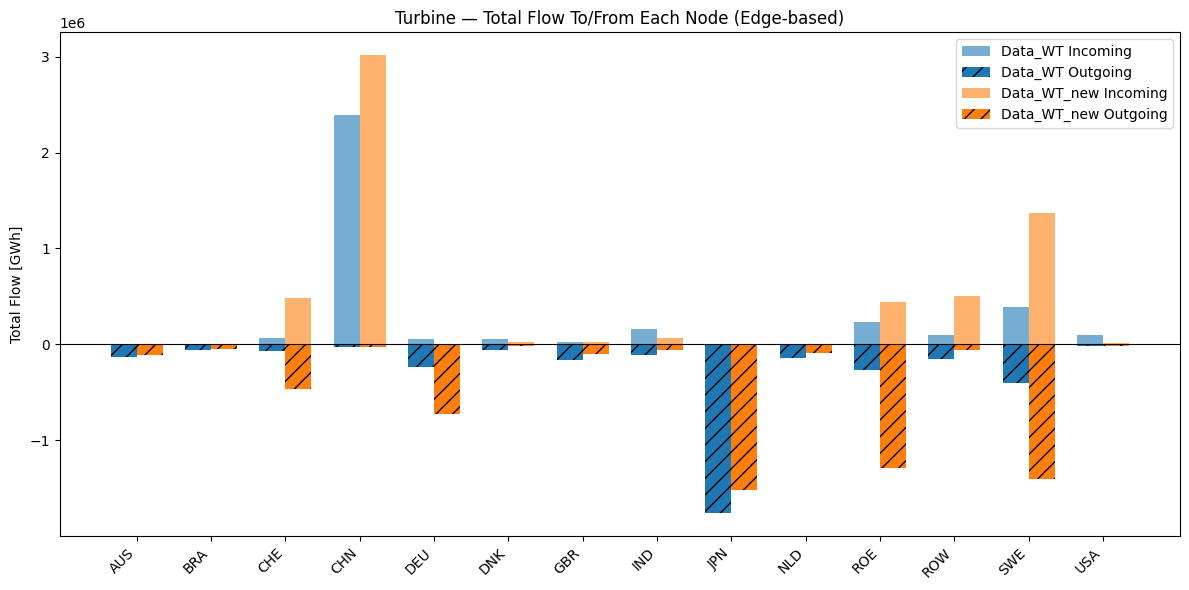

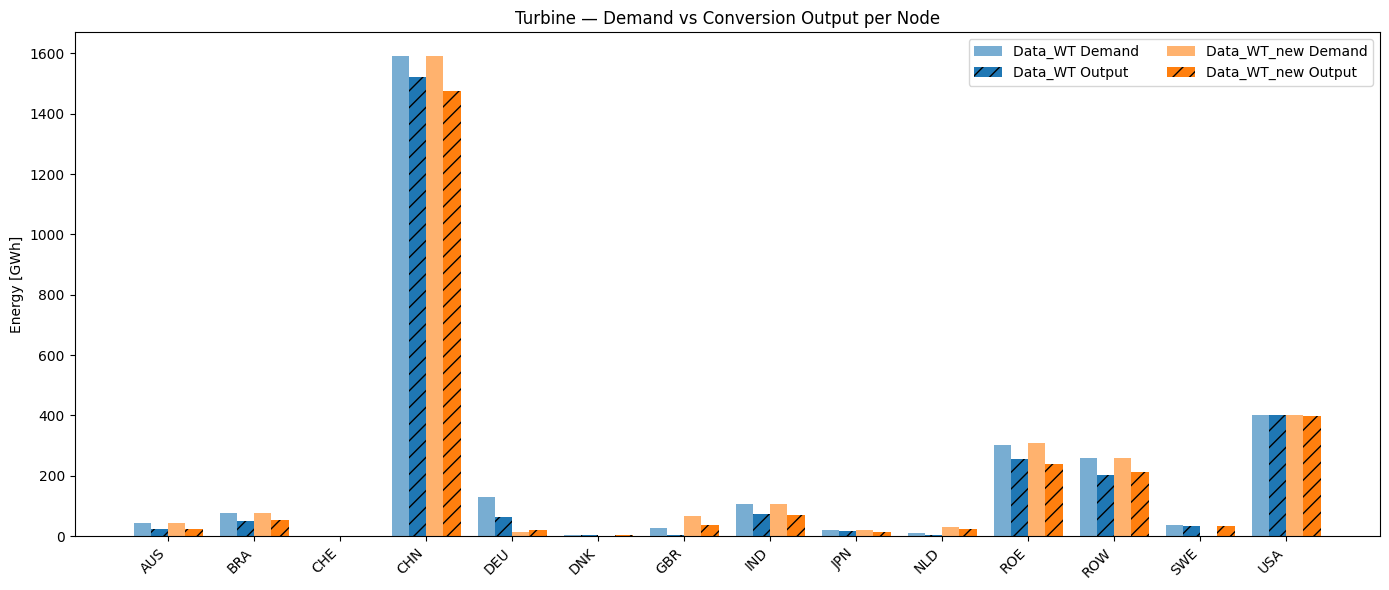

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = 'Data_WT'
dataset_name_2 = 'Data_WT_new'
technology_filter = "Turbine_Installation"
carrier_filter = "Turbine"

r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Save Paths ===
save_plots = False
save_path = Path(
    r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\conversion_flow_comparison")
csv_export_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")
os.makedirs(save_path, exist_ok=True)
os.makedirs(csv_export_path, exist_ok=True)

# === Style Settings ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}



def plot_total_flow_per_node_turbine_edge_based():
    var_name = "flow_transport"
    df1 = r1.get_full_ts(var_name).reset_index()
    df2 = r2.get_full_ts(var_name).reset_index()

    # Filter for Turbine carrier
    if "carrier" in df1.columns:
        df1 = df1[df1["carrier"] == carrier_filter]
    if "carrier" in df2.columns:
        df2 = df2[df2["carrier"] == carrier_filter]

    if "edge" not in df1.columns or "edge" not in df2.columns:
        print("❌ Edge column not found in flow_transport data.")
        return

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    # Compute total flow across time
    df1["total_flow"] = df1[time_cols].sum(axis=1)
    df2["total_flow"] = df2[time_cols].sum(axis=1)

    # Split edge into origin and destination
    def expand_edges(df):
        edge_split = df["edge"].str.split("-", expand=True)
        df["origin"] = edge_split[0]
        df["destination"] = edge_split[1]
        return df

    df1 = expand_edges(df1)
    df2 = expand_edges(df2)

    # Group incoming and outgoing
    def get_node_flows(df):
        incoming = df.groupby("destination")["total_flow"].sum().rename("Incoming")
        outgoing = df.groupby("origin")["total_flow"].sum().rename("Outgoing")
        return pd.concat([incoming, outgoing], axis=1).fillna(0)

    combined1 = get_node_flows(df1)
    combined2 = get_node_flows(df2)

    # Get all nodes involved
    all_nodes = sorted(set(combined1.index).union(combined2.index))

    # Plotting
    width = 0.35
    x = range(len(all_nodes))
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar([i - width/2 for i in x], combined1.reindex(all_nodes)["Incoming"], width=width,
           label=f"{dataset_name_1} Incoming", color=colors[dataset_name_1], alpha=0.6)
    ax.bar([i - width/2 for i in x], -combined1.reindex(all_nodes)["Outgoing"], width=width,
           label=f"{dataset_name_1} Outgoing", color=colors[dataset_name_1], alpha=1.0, hatch='//')

    ax.bar([i + width/2 for i in x], combined2.reindex(all_nodes)["Incoming"], width=width,
           label=f"{dataset_name_2} Incoming", color=colors[dataset_name_2], alpha=0.6)
    ax.bar([i + width/2 for i in x], -combined2.reindex(all_nodes)["Outgoing"], width=width,
           label=f"{dataset_name_2} Outgoing", color=colors[dataset_name_2], alpha=1.0, hatch='//')

    ax.set_ylabel("Total Flow [GWh]")
    ax.set_title(f"Turbine — Total Flow To/From Each Node (Edge-based)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_nodes, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    plt.tight_layout()

    if save_plots:
        plt.savefig(save_path / f"{var_name}_{carrier_filter}_edge_inout_nodes.pdf", format='pdf', bbox_inches='tight')
    plt.show()




def plot_turbine_demand_vs_conversion_output():
    var_demand = "demand"
    var_conversion = "flow_conversion_output"

    # Load and filter data
    df1_d = r1.get_full_ts(var_demand).reset_index()
    df2_d = r2.get_full_ts(var_demand).reset_index()
    df1_d = df1_d[df1_d["carrier"] == carrier_filter]
    df2_d = df2_d[df2_d["carrier"] == carrier_filter]

    df1_c = r1.get_full_ts(var_conversion).reset_index()
    df2_c = r2.get_full_ts(var_conversion).reset_index()
    df1_c = df1_c[df1_c["technology"] == technology_filter]
    df2_c = df2_c[df2_c["technology"] == technology_filter]

    time_cols = [col for col in df1_d.columns if isinstance(col, (int, float))]

    # Sum over time
    df1_d["total_demand"] = df1_d[time_cols].sum(axis=1)
    df2_d["total_demand"] = df2_d[time_cols].sum(axis=1)
    df1_c["total_output"] = df1_c[time_cols].sum(axis=1)
    df2_c["total_output"] = df2_c[time_cols].sum(axis=1)

    demand1 = df1_d.groupby("node")["total_demand"].sum().rename("Demand")
    demand2 = df2_d.groupby("node")["total_demand"].sum().rename("Demand")
    output1 = df1_c.groupby("node")["total_output"].sum().rename("Output")
    output2 = df2_c.groupby("node")["total_output"].sum().rename("Output")

    all_nodes = sorted(set(demand1.index).union(demand2.index).union(output1.index).union(output2.index))

    width = 0.2
    x = range(len(all_nodes))
    fig, ax = plt.subplots(figsize=(14, 6))

    # Dataset 1
    ax.bar([i - width * 1.5 for i in x], demand1.reindex(all_nodes), width=width,
           label=f"{dataset_name_1} Demand", color=colors[dataset_name_1], alpha=0.6)
    ax.bar([i - width * 0.5 for i in x], output1.reindex(all_nodes), width=width,
           label=f"{dataset_name_1} Output", color=colors[dataset_name_1], alpha=1.0, hatch='//')

    # Dataset 2
    ax.bar([i + width * 0.5 for i in x], demand2.reindex(all_nodes), width=width,
           label=f"{dataset_name_2} Demand", color=colors[dataset_name_2], alpha=0.6)
    ax.bar([i + width * 1.5 for i in x], output2.reindex(all_nodes), width=width,
           label=f"{dataset_name_2} Output", color=colors[dataset_name_2], alpha=1.0, hatch='//')

    ax.set_ylabel("Energy [GWh]")
    ax.set_title("Turbine — Demand vs Conversion Output per Node")
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_nodes, rotation=45, ha='right')
    ax.legend(ncol=2)
    plt.tight_layout()

    if save_plots:
        plt.savefig(save_path / "turbine_demand_vs_output_by_node.pdf", format='pdf', bbox_inches='tight')
    plt.show()



# === Run All Plots ===
plot_total_flow_per_node_turbine_edge_based()
plot_turbine_demand_vs_conversion_output()



In [2]:
unit = r1.get_unit('flow_transport')
unit

technology
Aluminium_transport            GW * h
Bauxite_transport              GW * h
Blade_transport                GW * h
Carbon_Fiber_transport         GW * h
Concrete_transport             GW * h
Copper_Ore_transport           GW * h
Copper_transport               GW * h
Iron_Ore_transport             GW * h
Limestone_transport            GW * h
Nacelle_transport              GW * h
Oil_transport                  GW * h
Permanent_Magnets_transport    GW * h
REE_Ore_transport              GW * h
REE_transport                  GW * h
Steel_transport                GW * h
Tower_transport                GW * h
Turbine_transport              GW * h
Name: units, dtype: object